## Bases de datos

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
activo_1='MSFT'
activo_2='NVDA'

mft=yf.download(activo_1, period="1y" ,interval='1d', auto_adjust=False)
nvidia=yf.download(activo_2, period="1y" ,interval='1d', auto_adjust=False)
datos_empresas=pd.DataFrame()
datos_empresas[activo_1]=mft['Close']
datos_empresas[activo_2]=nvidia['Close']
rendimientos_1= np.log(datos_empresas[activo_1]/ datos_empresas[activo_1].shift(1)).dropna()
rendimientos_2= np.log(datos_empresas[activo_2]/ datos_empresas[activo_2].shift(1)).dropna()
datos_empresas[f'rend_{activo_1}']=rendimientos_1
datos_empresas[f'rend_{activo_2}']=rendimientos_2
datos_empresas

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,MSFT,NVDA,rend_MSFT,rend_NVDA
Date,,,,
2025-03-04,388.609985,115.989998,NaN,NaN
2025-03-05,401.019989,117.300003,0.031435,0.011231
2025-03-06,396.890015,110.570000,-0.010352,-0.059086
2025-03-07,393.309998,112.690002,-0.009061,0.018992
2025-03-10,380.160004,106.980003,-0.034006,-0.051999
...,...,...,...,...
2026-02-26,401.720001,184.889999,0.002792,-0.056106
2026-02-27,392.739990,177.190002,-0.022608,-0.042538
2026-03-02,398.549988,182.479996,0.014685,0.029418


## Paso 1.Determinación de las distribuciones marginales asociadas a cada una de las variables en función de las muestras de datos disponibles.

Se usa KDE (Kernel Density Estimation)
1. Estima la distribución de probabilidad de los rendimientos usando kernels gaussianos.
2. En lugar de asumir una distribución normal, se adapta a la forma real de los datos

In [3]:
from scipy.integrate import quad
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
def compute_empirical_cdf(kde, x_values):
    """
    Calcular CDF empírica
    """
    cdf_values = np.zeros_like(x_values)

    for i, x in enumerate(x_values):
        result, _ = quad(kde, -np.inf, x) # Integrar la KDE desde -infinito hasta x
        cdf_values[i] = result

    return cdf_values

def transform_to_uniform(returns_series):
    """
    Transformar realizaciones de X a variables uniformes U
    """
    returns = returns_series.dropna().values

    # Estimar KDE
    kde = stats.gaussian_kde(returns)

    # Calcular CDF empírica para cada observación
    uniform_transformed = np.array([quad(kde, -np.inf, x)[0] for x in returns])

    return uniform_transformed
uniform_data = {}
for idx in datos_empresas[[f'rend_{activo_1}',f'rend_{activo_2}' ]].columns:
    uniform_data[idx] = transform_to_uniform(datos_empresas[idx])

uniform_df = pd.DataFrame(uniform_data)

In [4]:
rend_1=datos_empresas[f'rend_{activo_1}']
rend_2=datos_empresas[f'rend_{activo_2}']
f_x=uniform_df[f'rend_{activo_1}']
g_y=uniform_df[f'rend_{activo_2}']

In [5]:
uniform_df[[f'rend_{activo_1}',f'rend_{activo_2}' ]].describe()

,rend_MSFT,rend_NVDA
count,251.000000,251.000000
mean,0.500000,0.500000
std,0.272824,0.276835
min,0.001992,0.003755
25%,0.278376,0.291041
50%,0.504737,0.501376
75%,0.696422,0.732703
max,0.998008,0.998008


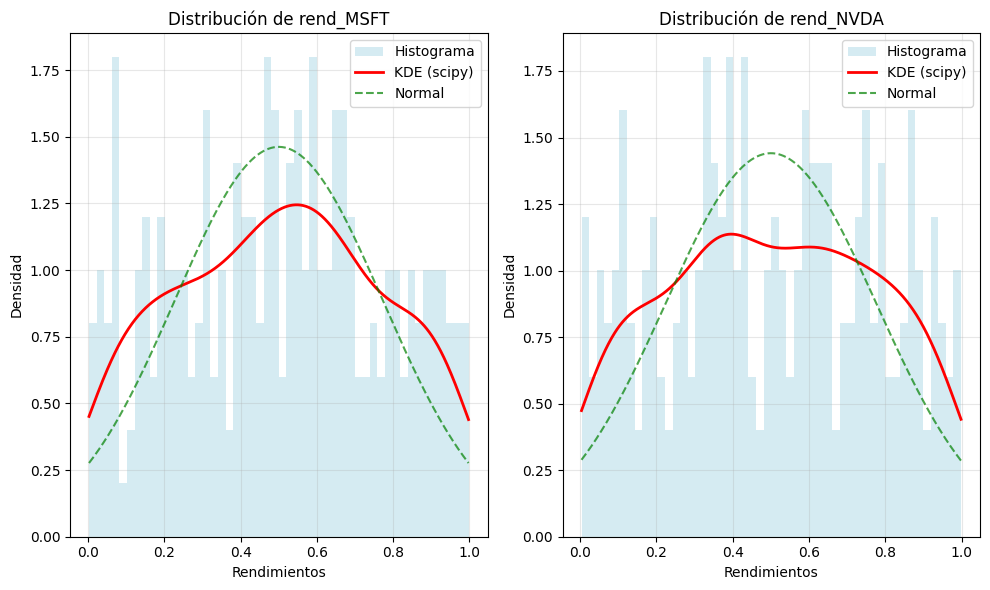

In [6]:
import seaborn as sns
from scipy import stats
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt
def plot_kde_scipy(returns_df, indices=None):
    if indices is None:
        indices = [f'rend_{activo_1}',f'rend_{activo_2}']

    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        if i >= len(axes):
            break

        returns = returns_df[idx].dropna()
        kde = stats.gaussian_kde(returns)# Estimación KDE con scipy
        x_range = np.linspace(returns.min(), returns.max(), 1000)
        kde_values = kde.evaluate(x_range)
        axes[i].hist(returns, bins=50, density=True, alpha=0.5,
                    color='lightblue', label='Histograma')
        axes[i].plot(x_range, kde_values, 'r-', linewidth=2,
                    label='KDE (scipy)')


        mu, sigma = returns.mean(), returns.std() # Comparar con distribución normal
        normal_pdf = stats.norm.pdf(x_range, mu, sigma)
        axes[i].plot(x_range, normal_pdf, 'g--', alpha=0.7,
                    label='Normal')

        axes[i].set_title(f'Distribución de {idx}')
        axes[i].set_xlabel('Rendimientos')
        axes[i].set_ylabel('Densidad')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
plot_kde_scipy(uniform_df)

## 2.Pruebas Gráficas y Teóricas de Dependencia.

In [7]:
uniform_df[[f'rend_{activo_1}',f'rend_{activo_2}' ]].corr(method='spearman') ## usa pearson por defecto, se puede cambiar dependniendo de los datos
## method='kendall' para tau de kendall
## method='spearman'

,rend_MSFT,rend_NVDA
rend_MSFT,1.00000,0.51436
rend_NVDA,0.51436,1.00000


array([[<Axes: xlabel='rend_MSFT', ylabel='rend_MSFT'>,
        <Axes: xlabel='rend_NVDA', ylabel='rend_MSFT'>],
       [<Axes: xlabel='rend_MSFT', ylabel='rend_NVDA'>,
        <Axes: xlabel='rend_NVDA', ylabel='rend_NVDA'>]], dtype=object)

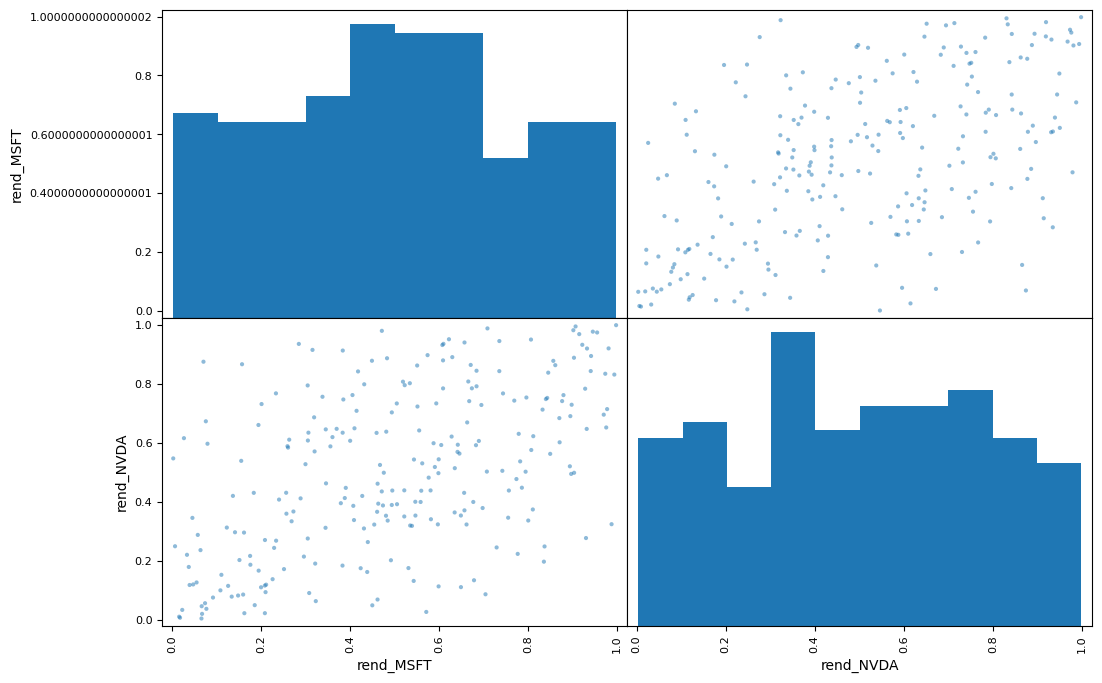

In [8]:
pd.plotting.scatter_matrix(uniform_df[[f'rend_{activo_1}',f'rend_{activo_2}' ]], figsize=(12, 8))

##3. Elegir una familia de cópulas.

Clayton.\
Fuerte dependencia en colas inferiores: Captura cuando las variables tienden a moverse juntas en valores bajos.\
\
Gumbel.\
Fuerte dependencia en colas superiores: Captura cuando las variables tienden a moverse juntas en valores altos

In [9]:
def copula_empirica(u, v):
    """
    Calcula la cópula empírica bivariada usando el enfoque de rango
    C_n(u,v) = (1/(n+1)) * Σ I(U_i ≤ u, V_i ≤ v)
    """
    n = len(u)
    C_emp = np.zeros(n)

    for i in range(n):
        C_emp[i] = np.sum((u <= u[i]) & (v <= v[i])) / (n + 1)

    return C_emp

def transformar_a_copula_empirica(returns_series1, returns_series2):
    """
    Transforma los rendimientos a cópula empírica usando rangos
    """
    data = pd.DataFrame({
        'x': returns_series1.dropna(),
        'y': returns_series2.dropna()
    }).dropna()

    n = len(data)
    data['rank_x'] = data['x'].rank() / (n + 1)
    data['rank_y'] = data['y'].rank() / (n + 1)

    return data['rank_x'].values, data['rank_y'].values

In [10]:
u,v=transformar_a_copula_empirica(rend_1,rend_2)

## Estimar los parámetros (Calibración) y evaluar el ajuste

In [14]:
import sympy as sp
import numpy as np
from scipy.optimize import minimize
from scipy import stats
import pandas as pd

def estimar_parametros_copula(u, v):
    u_sym, v_sym, theta_sym = sp.symbols('u v theta', positive=True, real=True)

    resultados = []

    # Copula de Clayton
    C_clayton = (u_sym**(-theta_sym) + v_sym**(-theta_sym) - 1)**(-1/theta_sym)
    densidad_clayton = sp.diff(sp.diff(C_clayton, u_sym), v_sym)
    densidad_clayton_simp = sp.simplify(densidad_clayton)
    densidad_clayton_func = sp.lambdify((u_sym, v_sym, theta_sym), densidad_clayton_simp, 'numpy')
    C_clayton_func = sp.lambdify((u_sym, v_sym, theta_sym), C_clayton, 'numpy')

    # Copula de Gumbel
    a = (-sp.log(u_sym))**theta_sym
    b = (-sp.log(v_sym))**theta_sym
    C_gumbel = sp.exp(-(a + b)**(1/theta_sym))
    densidad_gumbel = sp.diff(sp.diff(C_gumbel, u_sym), v_sym)
    densidad_gumbel_simp = sp.simplify(densidad_gumbel)
    densidad_gumbel_func = sp.lambdify((u_sym, v_sym, theta_sym), densidad_gumbel_simp, 'numpy')
    C_gumbel_func = sp.lambdify((u_sym, v_sym, theta_sym), C_gumbel, 'numpy')

    # Copula de Frank
    C_frank = -1/theta_sym * sp.log(1 + ((sp.exp(-theta_sym * u_sym) - 1) * (sp.exp(-theta_sym * v_sym) - 1)) / (sp.exp(-theta_sym) - 1))
    densidad_frank = sp.diff(sp.diff(C_frank, u_sym), v_sym)
    densidad_frank_simp = sp.simplify(densidad_frank)
    densidad_frank_func = sp.lambdify((u_sym, v_sym, theta_sym), densidad_frank_simp, 'numpy')
    C_frank_func = sp.lambdify((u_sym, v_sym, theta_sym), C_frank, 'numpy')


    # Funciones de verosimilitud
    def verosimilitud_clayton(theta): #θ[0,inf] sin 0
        if theta <= 0:
            return 0.00001
        log_lik = 0
        for i in range(len(u)):
            try:
                dens = densidad_clayton_func(u[i], v[i], theta)
                if dens > 0:
                    log_lik += np.log(dens)
            except:
                continue
        return -log_lik if not np.isnan(-log_lik) else 1

    def verosimilitud_gumbel(theta): #θ[1,inf]
        if theta < 1:
            return 1.000001
        log_lik = 0
        for i in range(len(u)):
            try:
                dens = densidad_gumbel_func(u[i], v[i], theta)
                if dens > 0 and not np.isnan(dens):
                    log_lik += np.log(dens)
            except:
                continue
        return -log_lik if not np.isnan(-log_lik) else 1

    # Parámetros
    resultado_clayton = minimize(verosimilitud_clayton, [1.0], method='L-BFGS-B', bounds=[(0.001, 10)])
    param_clayton = resultado_clayton.x[0]

    resultado_gumbel = minimize(verosimilitud_gumbel, [2.0], method='L-BFGS-B', bounds=[(1.001, 10)])
    param_gumbel = resultado_gumbel.x[0]

    # pruebas de bondad de ajuste AD y IAD
    def prueba_ad_copula(u, v, copula_func, theta):
        n = len(u)
        C_emp = copula_empirica(u, v)  # Calcular cópula empírica
        C_teo = np.array([copula_func(u[i], v[i], theta) for i in range(n)]) # Calcular cópula teórica

        indices_ordenados = np.argsort(C_teo)
        C_teo_sorted = C_teo[indices_ordenados]
        C_emp_sorted = C_emp[indices_ordenados]

        # AD
        i = np.arange(1, n + 1)
        ad_stat = -n - np.sum((2*i - 1) * (np.log(C_teo_sorted) + np.log(1 - C_emp_sorted[::-1]))) / n

        return ad_stat

    def prueba_iad_copula(u, v, copula_func, theta):
        """Prueba Integral Anderson-Darling comparando con cópula empírica"""
        n = len(u)
        C_emp = copula_empirica(u, v)
        C_teo = np.array([copula_func(u[i], v[i], theta) for i in range(n)])
        iad_stat = np.sum((C_teo - C_emp)**2)

        return iad_stat
    ad_clayton = prueba_ad_copula(u, v, C_clayton_func, param_clayton)
    iad_clayton = prueba_iad_copula(u, v, C_clayton_func, param_clayton)


    ad_gumbel = prueba_ad_copula(u, v, C_gumbel_func, param_gumbel)
    iad_gumbel = prueba_iad_copula(u, v, C_gumbel_func, param_gumbel)

    resultados = [
        {'Cópula': 'Clayton', 'Parámetro': param_clayton, 'Log-Lik': -resultado_clayton.fun,'AD': ad_clayton,'IAD': iad_clayton},
        {'Cópula': 'Gumbel', 'Parámetro': param_gumbel, 'Log-Lik': -resultado_gumbel.fun,'AD': ad_gumbel,'IAD': iad_gumbel }
    ]

    tabla = pd.DataFrame(resultados)

    return tabla, densidad_clayton_simp, densidad_gumbel_simp

In [15]:
tabla_resultados, dens_clayton, dens_gumbel = estimar_parametros_copula(f_x, g_y)
tabla_resultados

,Cópula,Parámetro,Log-Lik,AD,IAD
0,Clayton,0.957943,38.130462,41.442149,0.168191
1,Gumbel,1.574382,40.201932,39.088564,0.065625


## Simular cópula.

In [16]:
import sympy as sp
import numpy as np
from scipy.special import lambertw
t, theta_sym, z, l_sym = sp.symbols('t theta z l_sym', positive=True)
phi = (-sp.log(t))**theta_sym # generador de Gumbel
phi_prima = sp.diff(phi, t)
k_c = t - phi/phi_prima
l_z = k_c.subs(t, z)
eq = sp.Eq(l_z, l_sym)
z_expr = -l_sym * theta_sym / sp.LambertW(-l_sym * theta_sym * sp.exp(-theta_sym))
z_num = sp.lambdify((theta_sym, l_sym), z_expr, 'numpy')

def solve_z(theta, l):
    x = -l * theta * np.exp(-theta)
    w = lambertw(x, k=-1)
    w = np.real(w) ##parte real

    z = -l * theta / w

    return z

def copula_gumbel(n, theta):
    w = np.random.uniform(0, 1, n)
    l = np.random.uniform(0, 1, n)
    z_vals = solve_z(theta, l)

    #simular u,v
    U = 1 / (1 + w * (-np.log(z_vals))**theta)
    V = 1 / (1 + (1 - w) * (-np.log(z_vals))**theta)

    return U, V

In [17]:
def copula_Cook_Jonhson(n, theta):
    """
    1. simular u,q ~U[0,1]
    2. compute v = C^{-1}(q|u) = ([q^{-theta/(1+theta)} - 1] * u^{-theta} + 1)^{-1/theta}
    3. Generar pares (u,v)
    """
    u = np.random.uniform(0, 1, n)
    q = np.random.uniform(0, 1, n)
    v = ((q**(-theta/(1 + theta)) - 1) * u**(-theta) + 1)**(-1/theta)

    return u,v


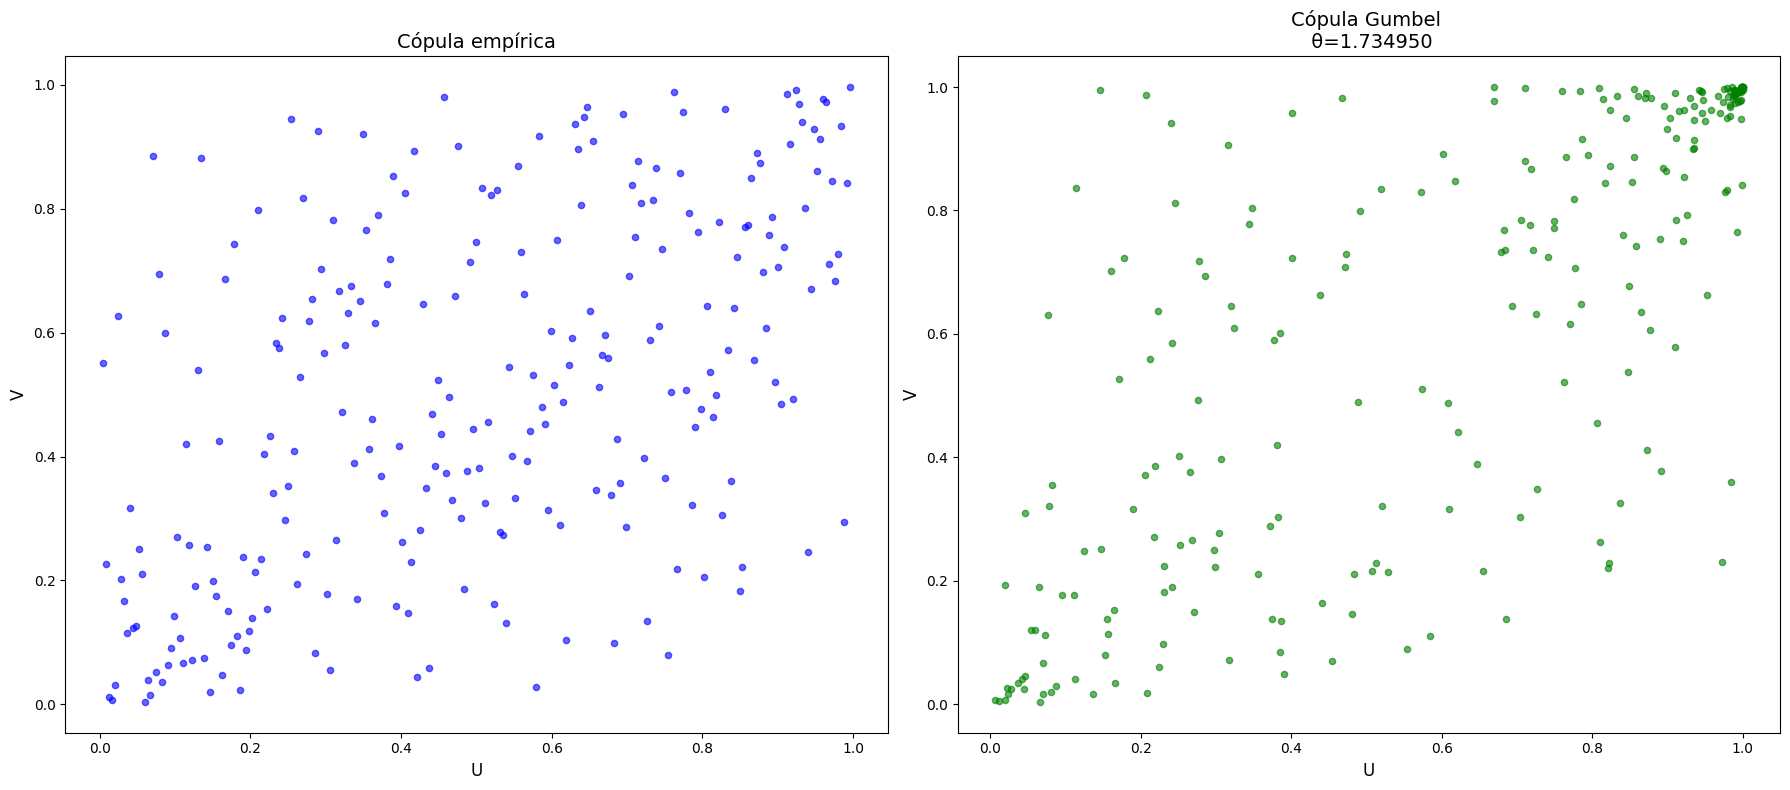

In [18]:
plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
plt.scatter(u, v, alpha=0.6, s=20, color='blue')
plt.xlabel('U', fontsize=12)
plt.ylabel('V', fontsize=12)
plt.title('Cópula empírica', fontsize=14)
'''
plt.subplot(1, 3, 2)
a,b=copula_gumbel(len(datos_empresas), 1.245688)
plt.scatter(a, b, alpha=0.6, s=20, color='red')
plt.xlabel('U', fontsize=12)
plt.ylabel('V', fontsize=12)
plt.title('Cópula Clayton \n θ=1.245688 ', fontsize=14)
'''
plt.subplot(1, 2, 2)
c,d=copula_gumbel(len(datos_empresas), 2.5)  # Tercera cópula
plt.scatter(c, d, alpha=0.6, s=20, color='green')
plt.xlabel('U', fontsize=12)
plt.ylabel('V', fontsize=12)
plt.title('Cópula Gumbel \n θ=1.734950', fontsize=14)

plt.tight_layout()
plt.show()